In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

import json
with open("config.json") as f:
    config = json.load(f)
network_order = config['networks']

# Average spectrum

In [2]:
dfs = []
stats_dfs = []
stats_dfs_nomotion = []
for strategy in config['strategies']:
    try:
        df_strategy = pd.read_csv('data/results/spectra_by_frequency_network_'+strategy+'.csv', low_memory=False)
        df_strategy['strategy'] = strategy
        dfs.append(df_strategy)
        try:
            stats_strategy = pd.read_csv('data/results/logpower_stats_by_frequency_network_'+strategy+'_perm.csv')
        except FileNotFoundError:
            stats_strategy = pd.read_csv('data/results/logpower_stats_by_frequency_network_'+strategy+'.csv')
        stats_strategy['strategy'] = strategy
        stats_dfs.append(stats_strategy)
        try:
            stats_strategy_nomotion = pd.read_csv('data/results/logpower_stats_by_frequency_network_nomotion_'+strategy+'_perm.csv')
        except FileNotFoundError:
            stats_strategy_nomotion = pd.read_csv('data/results/logpower_stats_by_frequency_network_nomotion_'+strategy+'.csv')
        stats_strategy_nomotion['strategy'] = strategy
        stats_dfs_nomotion.append(stats_strategy_nomotion)
    except FileNotFoundError:
        print(f"File for strategy {strategy} not found, skipping.")

spectrum_df = pd.concat(dfs, ignore_index=True)
stats_df = pd.concat(stats_dfs, ignore_index=True)
stats_df = stats_df[stats_df['covariate']=='PPL_mcg_L']
stats_df = stats_df[stats_df['controlled']>=0.01]
stats_df_nomotion = pd.concat(stats_dfs_nomotion, ignore_index=True)
stats_df_nomotion = stats_df_nomotion[stats_df_nomotion['covariate']=='PPL_mcg_L']
stats_df_nomotion = stats_df_nomotion[stats_df_nomotion['controlled']>=0.01]

category_cols = ['subject', 'time_interval', 'strategy', 'network', 'frequency', 'scanner', 'num_vols']
numeric_cols = ['partial_residuals','partial_residuals_nomotion', 'log_power','PPL_mcg/L']
spectrum_df_avg_within_subject = spectrum_df.groupby(category_cols, as_index=False)[numeric_cols].mean()

File for strategy 9p-despike not found, skipping.
File for strategy ica-aroma not found, skipping.
File for strategy ica-aroma-gsr not found, skipping.


strategy, time interval, partial residuals

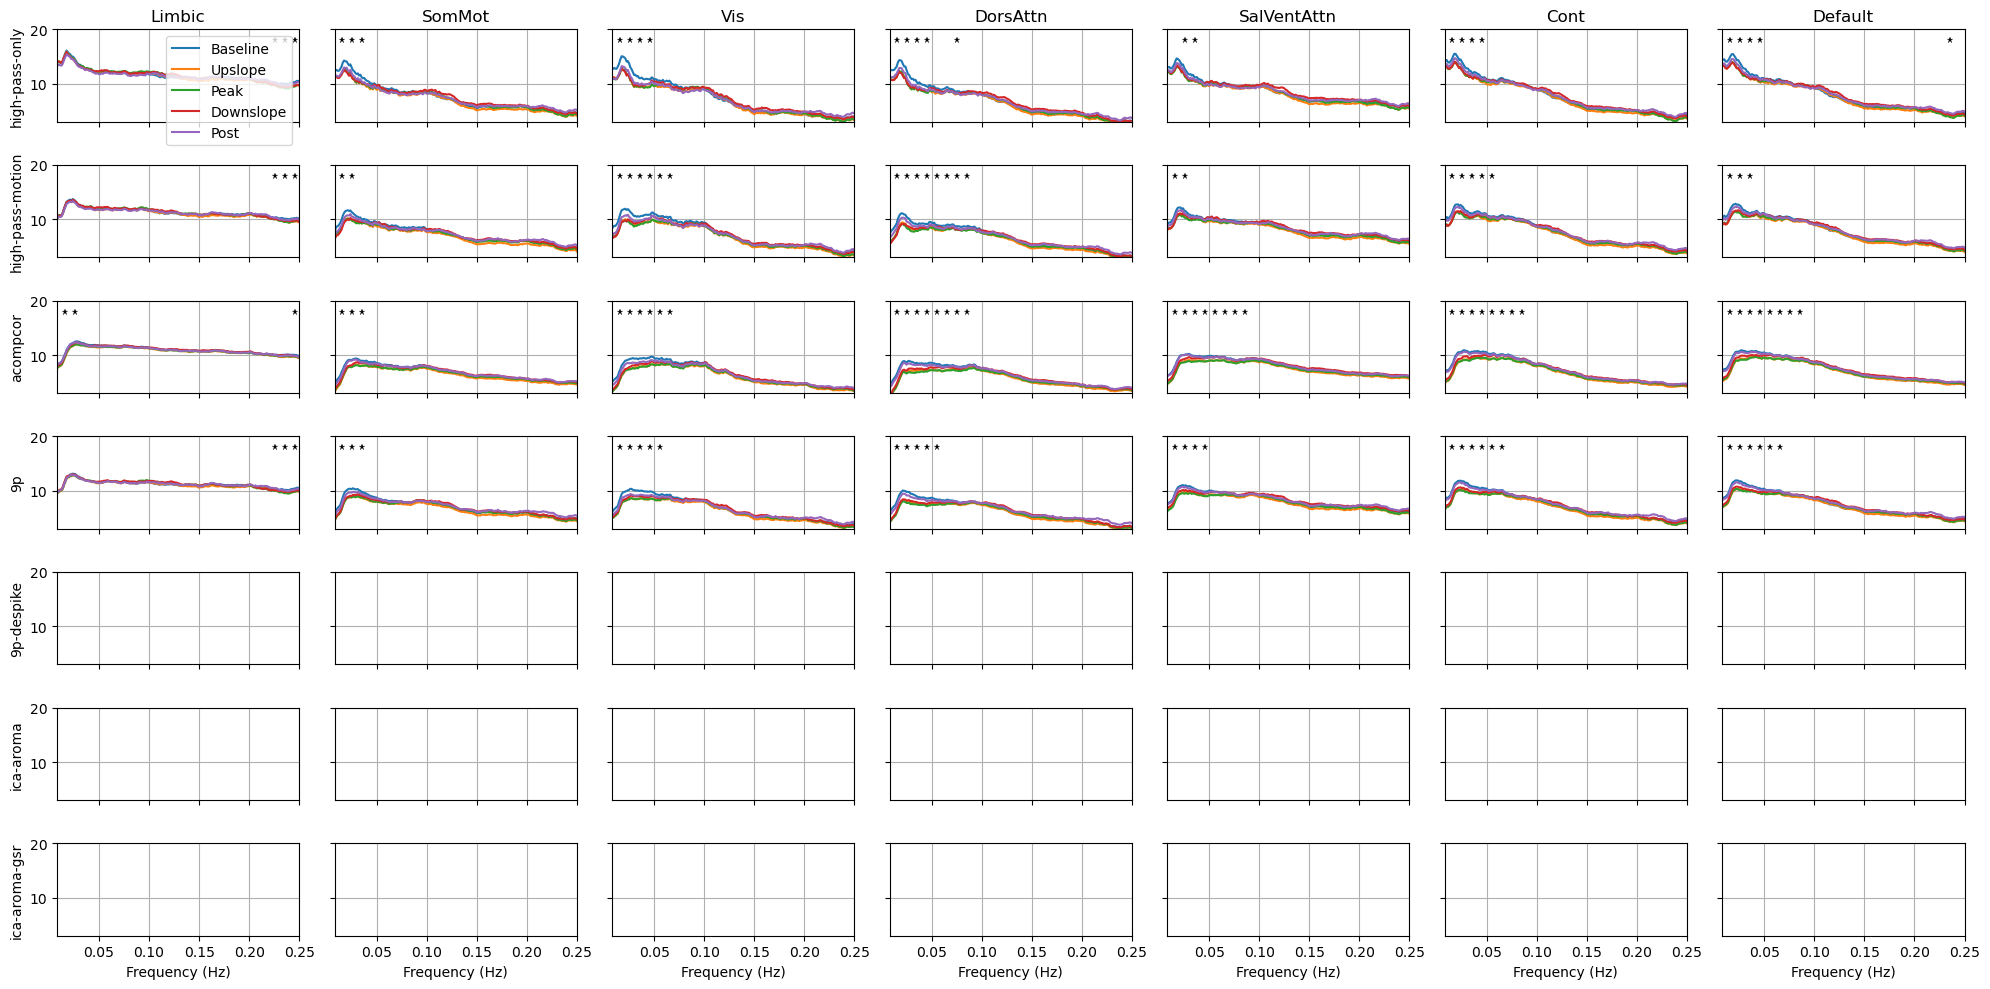

In [3]:
asterisk_loc = 18
fig,axs = plt.subplots(len(config['strategies']),7, figsize=(20, 10), sharex=True, sharey=True, layout='tight')
spectrum_df_avg = spectrum_df_avg_within_subject.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
frequencies = np.loadtxt('data/frequencies_MR45.txt')  
for s,strategy in enumerate(config["strategies"]):
    for n,network in enumerate(network_order):
        ax = axs[s,n]
        stat_reduced_df = stats_df[(stats_df['uncontrolled'] == network) & (stats_df['strategy'] == strategy)]
        for t,time_interval in enumerate(config["time_intervals"]):
            network_spectrum = spectrum_df_avg[(spectrum_df_avg['network'] == network) & (spectrum_df_avg['strategy'] == strategy) & (spectrum_df_avg['time_interval'] == time_interval)]
            
            ax.plot(network_spectrum['frequency'], network_spectrum['partial_residuals'], label=time_interval)

            # plot asterisks for significant changes
            if t==0:
                for i,row in stat_reduced_df.iterrows():
                    if row['pval'] < 0.05/7:
                        ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)

            if s == 6:
                ax.set_xlabel('Frequency (Hz)')
            ax.grid()
            # ax.legend(networks, loc='upper right')
            # ax.set_xlim([0, 0.25])  # Adjust x-axis limits as needed      
            if s == 0:
                ax.set_title(network)
            if s==0 and n==0:
                ax.legend(loc='upper right')
            if n == 0:
                ax.set_ylabel(strategy)  
            
            ax.set_ylim([3, 20])
            ax.set_xlim([0.008, 0.25])
            # ax.set_xscale('log')
# fig.savefig('figures/aggregated_power_maps/bands_partial_residuals.png', bbox_inches='tight', dpi=300)

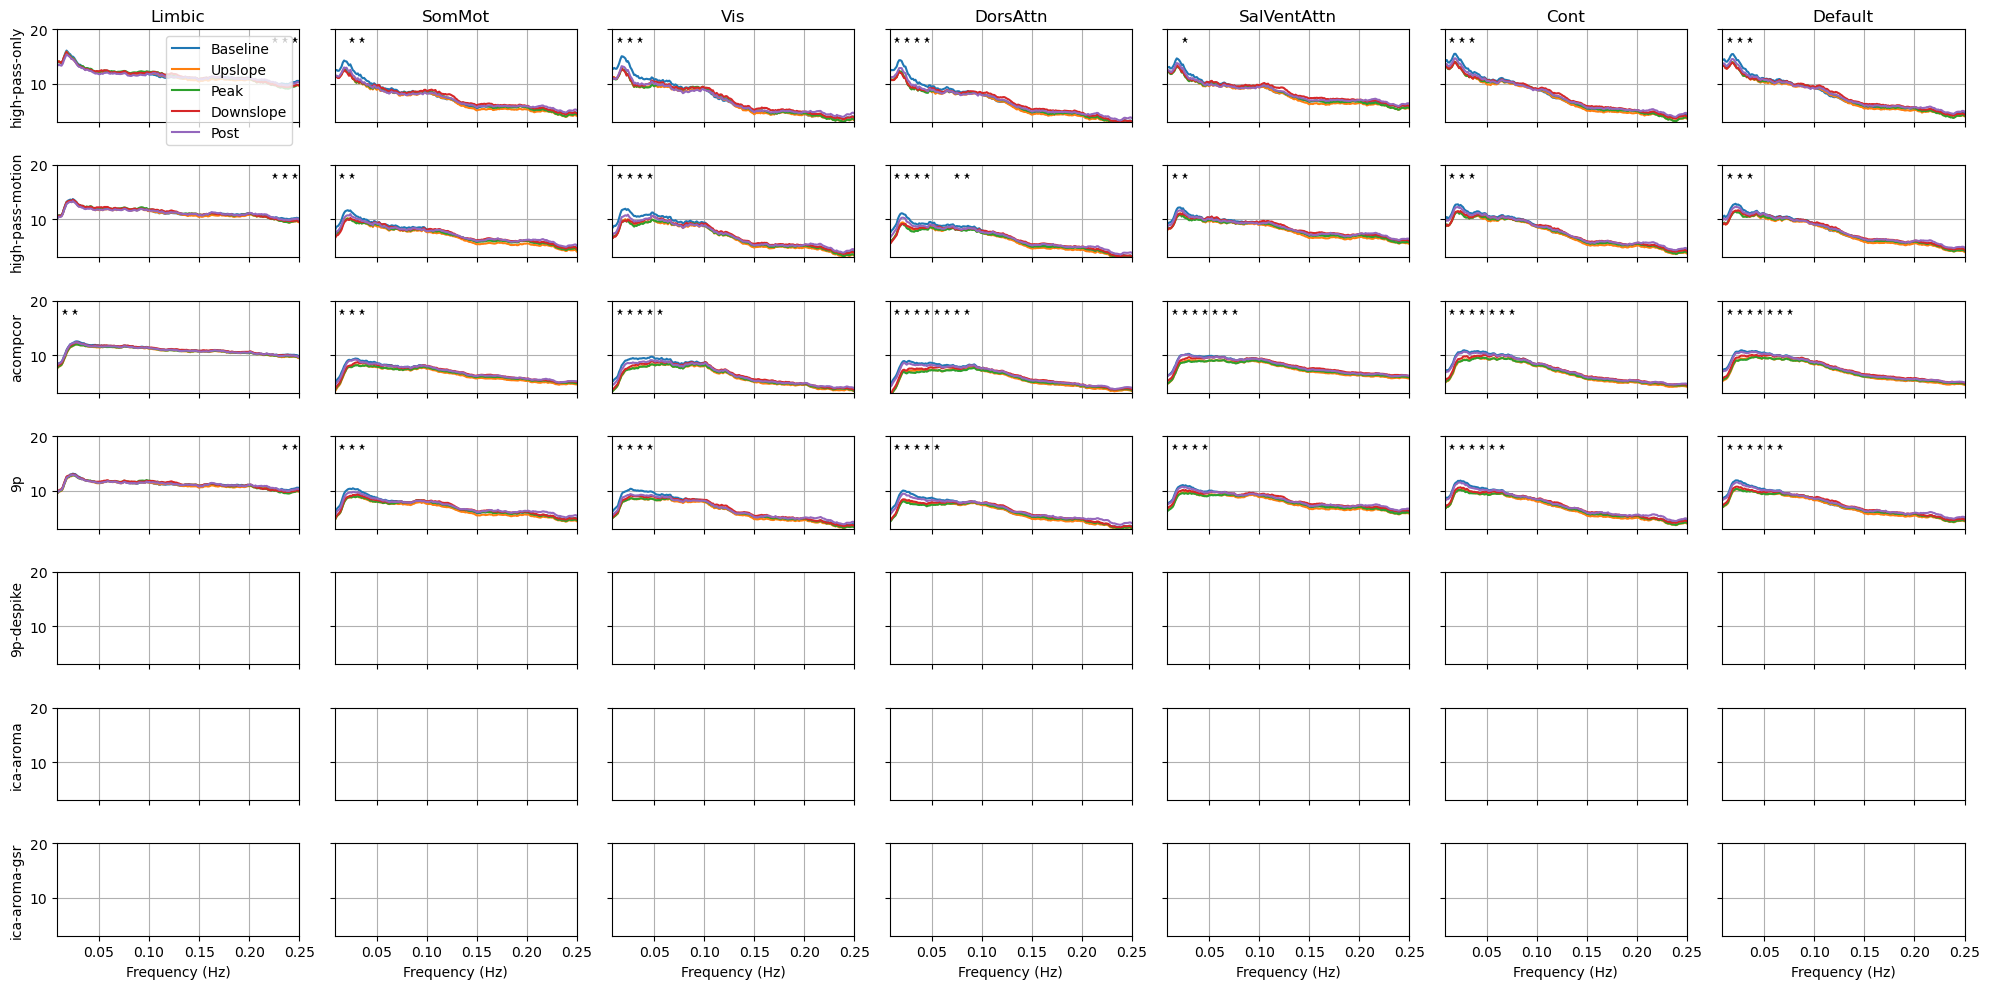

In [4]:
asterisk_loc = 18
fig,axs = plt.subplots(len(config['strategies']),7, figsize=(20, 10), sharex=True, sharey=True, layout='tight')
spectrum_df_avg = spectrum_df_avg_within_subject.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
frequencies = np.loadtxt('data/frequencies_MR45.txt')  
for s,strategy in enumerate(config["strategies"]):
    for n,network in enumerate(network_order):
        ax = axs[s,n]
        stat_reduced_df = stats_df[(stats_df['uncontrolled'] == network) & (stats_df['strategy'] == strategy)]
        for t,time_interval in enumerate(config["time_intervals"]):
            network_spectrum = spectrum_df_avg[(spectrum_df_avg['network'] == network) & (spectrum_df_avg['strategy'] == strategy) & (spectrum_df_avg['time_interval'] == time_interval)]
            
            ax.plot(network_spectrum['frequency'], network_spectrum['partial_residuals'], label=time_interval)

            # plot asterisks for significant changes
            if t==0:
                for i,row in stat_reduced_df.iterrows():
                    if row['pval_perm'] < 0.05/7:
                        ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)

            if s == 6:
                ax.set_xlabel('Frequency (Hz)')
            ax.grid()
            # ax.legend(networks, loc='upper right')
            # ax.set_xlim([0, 0.25])  # Adjust x-axis limits as needed      
            if s == 0:
                ax.set_title(network)
            if s==0 and n==0:
                ax.legend(loc='upper right')
            if n == 0:
                ax.set_ylabel(strategy)  
            
            ax.set_ylim([3, 20])
            ax.set_xlim([0.008, 0.25])
            # ax.set_xscale('log')
# fig.savefig('figures/aggregated_power_maps/bands_partial_residuals.png', bbox_inches='tight', dpi=300)

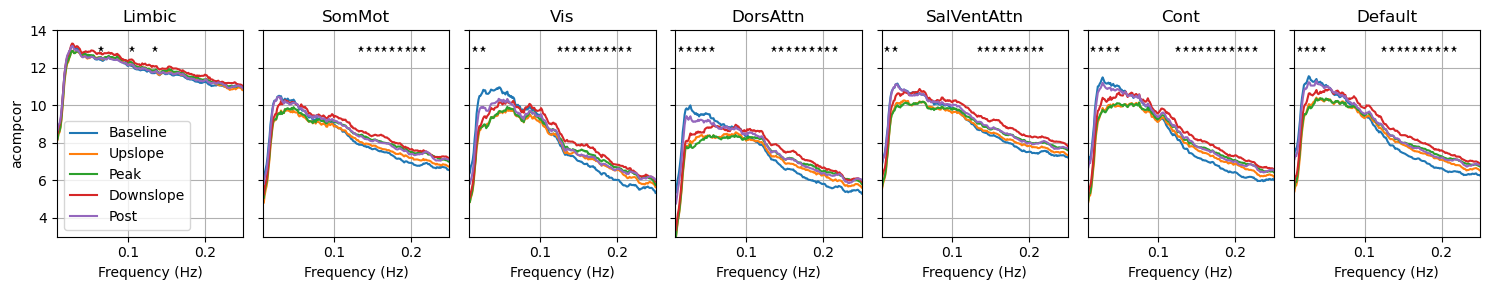

In [5]:
asterisk_loc = 13
fig,axs = plt.subplots(1,7, figsize=(15, 3), sharex=True, sharey=True, layout='tight')
spectrum_df_avg = spectrum_df_avg_within_subject.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
frequencies = np.loadtxt('data/frequencies_MR45.txt')  
strategy = 'acompcor' 
networks = network_order
for n,network in enumerate(networks):
    ax = axs[n]
    stat_reduced_df = stats_df_nomotion[(stats_df_nomotion['uncontrolled'] == network) & (stats_df_nomotion['strategy'] == strategy)]
    for t,time_interval in enumerate(config["time_intervals"]):
        network_spectrum = spectrum_df_avg[(spectrum_df_avg['network'] == network) & (spectrum_df_avg['strategy'] == strategy) & (spectrum_df_avg['time_interval'] == time_interval)]
        
        ax.plot(network_spectrum['frequency'], network_spectrum['partial_residuals_nomotion'], label=time_interval)

        # plot asterisks for significant changes
        if t==0:
            for i,row in stat_reduced_df.iterrows():
                if row['pval_perm'] < 0.05/7:
                    ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)

        ax.set_xlabel('Frequency (Hz)')
        ax.grid()
        # ax.legend(networks, loc='upper right')
        # ax.set_xlim([0, 0.25])  # Adjust x-axis limits as needed      
        ax.set_title(network)
        if n==0:
            ax.legend(loc='lower left')
            ax.set_ylabel(strategy)  
        
        ax.set_ylim([3,14])
        ax.set_xlim([0.008, 0.25])
        # ax.set_xscale('log')

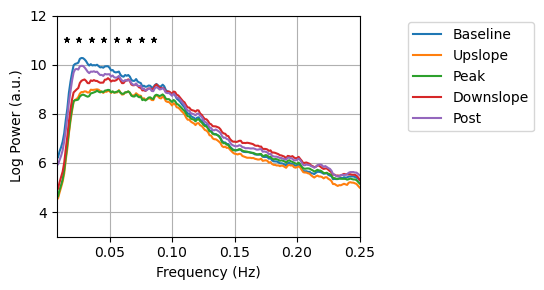

In [21]:
# make one plot which is averaged across networks
fig,ax = plt.subplots(1,1, figsize=(6, 3), sharex=True, sharey=True, layout='tight')
spectrum_df_avg = spectrum_df_avg_within_subject.groupby(['strategy', 'time_interval', 'frequency'], as_index=False)[numeric_cols].mean()
frequencies = np.loadtxt('data/frequencies_MR45.txt')  
strategy = 'acompcor'
for t,time_interval in enumerate(config["time_intervals"]):
    network_spectrum = spectrum_df_avg[(spectrum_df_avg['strategy'] == strategy) & (spectrum_df_avg['time_interval'] == time_interval)]
    
    ax.plot(network_spectrum['frequency'], network_spectrum['partial_residuals'], label=time_interval)

    # add the asterisks
    stat_reduced_df = stats_df[(stats_df['uncontrolled'] == 'Vis') & (stats_df['strategy'] == strategy)]
    for i,row in stat_reduced_df.iterrows():
        if row['pval'] < 0.05:
            ax.plot(row['controlled'],11, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)

    ax.set_xlabel('Frequency (Hz)')
    ax.grid()
    ax.set_ylabel('Log Power (a.u.)')
    # ax.set_title(f'Average across networks - {strategy}')
    ax.legend(loc='upper right',bbox_to_anchor=(1.6, 1))
    ax.set_ylim([3, 12])
    ax.set_xlim([0.008, 0.25])
    # ax.set_xscale('log')
fig.savefig('tmp.png', dpi=300, bbox_inches='tight', )

Text(0.5, 0.8, 'p-value (uncorrected): 3.87e-08')

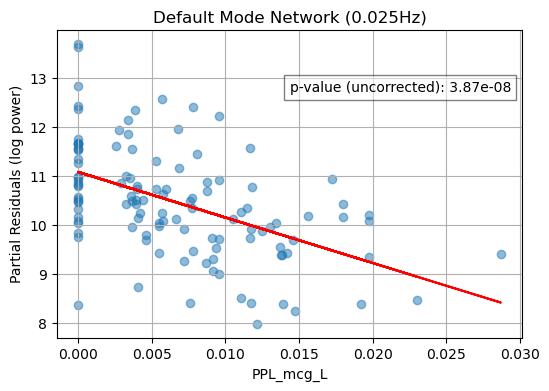

In [42]:
# zoom in on Default Mode Network, frequency 0.02Hz, plot a scatter plot of power vs PPL_mcg_L
network_spectrum = spectrum_df[(spectrum_df['network'] == 'Default') & (spectrum_df['strategy'] == 'acompcor') & (spectrum_df['frequency'] == 0.025)]
# remove na
network_spectrum = network_spectrum.dropna(subset=['PPL_mcg/L', 'partial_residuals_nomotion'])

plt.figure(figsize=(6,4))
plt.scatter(network_spectrum['PPL_mcg/L'], network_spectrum['partial_residuals_nomotion'], alpha=0.5)
# add line of best fit
m, b = np.polyfit(network_spectrum['PPL_mcg/L'], network_spectrum['partial_residuals_nomotion'], 1)
plt.plot(network_spectrum['PPL_mcg/L'], m*network_spectrum['PPL_mcg/L'] + b, color='red')
plt.xlabel('PPL_mcg_L')
plt.ylabel('Partial Residuals (log power)')
plt.title('Default Mode Network (0.025Hz)')
plt.grid()
# insert text box with p-value from stats_df
pval = stats_df_nomotion[(stats_df_nomotion['uncontrolled'] == 'Default') & (stats_df_nomotion['strategy'] == 'acompcor') & (stats_df_nomotion['controlled'] == 0.025625)]['pval'].values[0]
plt.text(0.5, 0.8, f'p-value (uncorrected): {pval:.2e}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))


Text(0.5, 0.8, 'p-value (uncorrected): 1.20e-04')

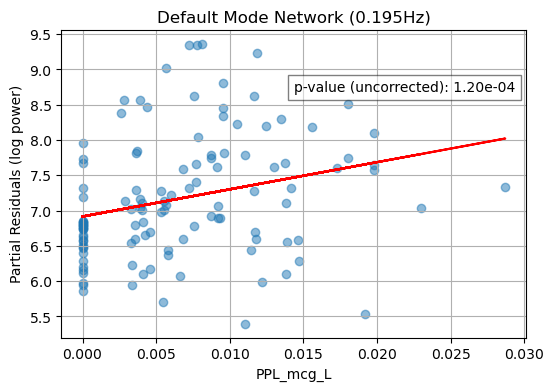

In [43]:
# zoom in on Default Mode Network, frequency 0.02Hz, plot a scatter plot of power vs PPL_mcg_L
network_spectrum = spectrum_df[(spectrum_df['network'] == 'Default') & (spectrum_df['strategy'] == 'acompcor') & (spectrum_df['frequency'] == 0.195)]
# remove na
network_spectrum = network_spectrum.dropna(subset=['PPL_mcg/L', 'partial_residuals_nomotion'])

plt.figure(figsize=(6,4))
plt.scatter(network_spectrum['PPL_mcg/L'], network_spectrum['partial_residuals_nomotion'], alpha=0.5)
# add line of best fit
m, b = np.polyfit(network_spectrum['PPL_mcg/L'], network_spectrum['partial_residuals_nomotion'], 1)
plt.plot(network_spectrum['PPL_mcg/L'], m*network_spectrum['PPL_mcg/L'] + b, color='red')
plt.xlabel('PPL_mcg_L')
plt.ylabel('Partial Residuals (log power)')
plt.title('Default Mode Network (0.195Hz)')
plt.grid()
# insert text box with p-value from stats_df
pval = stats_df_nomotion[(stats_df_nomotion['uncontrolled'] == 'Default') & (stats_df_nomotion['strategy'] == 'acompcor') & (stats_df_nomotion['controlled'] == 0.195625)]['pval'].values[0]
plt.text(0.5, 0.8, f'p-value (uncorrected): {pval:.2e}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))


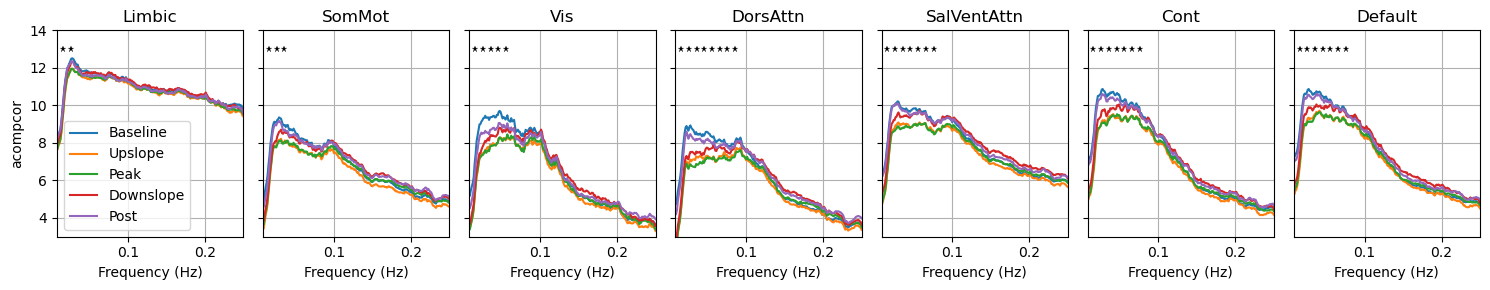

In [29]:
asterisk_loc = 13
fig,axs = plt.subplots(1,7, figsize=(15, 3), sharex=True, sharey=True, layout='tight')
spectrum_df_avg = spectrum_df_avg_within_subject.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
frequencies = np.loadtxt('data/frequencies_MR45.txt')  
strategy = 'acompcor' 
networks = network_order
for n,network in enumerate(networks):
    ax = axs[n]
    stat_reduced_df = stats_df[(stats_df['uncontrolled'] == network) & (stats_df['strategy'] == strategy)]
    for t,time_interval in enumerate(config["time_intervals"]):
        network_spectrum = spectrum_df_avg[(spectrum_df_avg['network'] == network) & (spectrum_df_avg['strategy'] == strategy) & (spectrum_df_avg['time_interval'] == time_interval)]
        
        ax.plot(network_spectrum['frequency'], network_spectrum['partial_residuals'], label=time_interval)

        # plot asterisks for significant changes
        if t==0:
            for i,row in stat_reduced_df.iterrows():
                if row['pval_perm'] < 0.05/7:
                    ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)

        ax.set_xlabel('Frequency (Hz)')
        ax.grid()
        # ax.legend(networks, loc='upper right')
        # ax.set_xlim([0, 0.25])  # Adjust x-axis limits as needed      
        ax.set_title(network)
        if n==0:
            ax.legend(loc='lower left')
            ax.set_ylabel(strategy)  
        
        ax.set_ylim([3,14])
        ax.set_xlim([0.008, 0.25])
        # ax.set_xscale('log')

Text(0.5, 0.8, 'p-value (uncorrected): 1.57e-11')

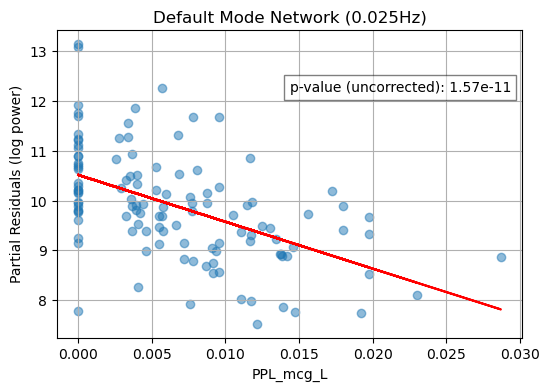

In [45]:
# zoom in on Default Mode Network, frequency 0.02Hz, plot a scatter plot of power vs PPL_mcg_L
network_spectrum = spectrum_df[(spectrum_df['network'] == 'Default') & (spectrum_df['strategy'] == 'acompcor') & (spectrum_df['frequency'] == 0.025)]
# remove na
network_spectrum = network_spectrum.dropna(subset=['PPL_mcg/L', 'partial_residuals'])

plt.figure(figsize=(6,4))
plt.scatter(network_spectrum['PPL_mcg/L'], network_spectrum['partial_residuals'], alpha=0.5)
# add line of best fit
m, b = np.polyfit(network_spectrum['PPL_mcg/L'], network_spectrum['partial_residuals'], 1)
plt.plot(network_spectrum['PPL_mcg/L'], m*network_spectrum['PPL_mcg/L'] + b, color='red')
plt.xlabel('PPL_mcg_L')
plt.ylabel('Partial Residuals (log power)')
plt.title('Default Mode Network (0.025Hz)')
plt.grid()
# insert text box with p-value from stats_df
pval = stats_df[(stats_df['uncontrolled'] == 'Default') & (stats_df['strategy'] == 'acompcor') & (stats_df['controlled'] == 0.025625)]['pval'].values[0]
plt.text(0.5, 0.8, f'p-value (uncorrected): {pval:.2e}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))


Text(0.5, 0.8, 'p-value (uncorrected): 3.33e-01')

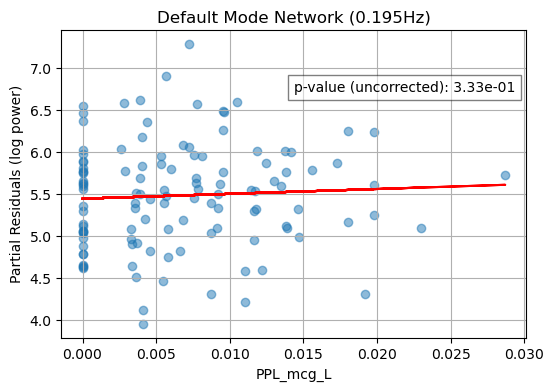

In [46]:
# zoom in on Default Mode Network, frequency 0.02Hz, plot a scatter plot of power vs PPL_mcg_L
network_spectrum = spectrum_df[(spectrum_df['network'] == 'Default') & (spectrum_df['strategy'] == 'acompcor') & (spectrum_df['frequency'] == 0.195)]
# remove na
network_spectrum = network_spectrum.dropna(subset=['PPL_mcg/L', 'partial_residuals'])

plt.figure(figsize=(6,4))
plt.scatter(network_spectrum['PPL_mcg/L'], network_spectrum['partial_residuals'], alpha=0.5)
# add line of best fit
m, b = np.polyfit(network_spectrum['PPL_mcg/L'], network_spectrum['partial_residuals'], 1)
plt.plot(network_spectrum['PPL_mcg/L'], m*network_spectrum['PPL_mcg/L'] + b, color='red')
plt.xlabel('PPL_mcg_L')
plt.ylabel('Partial Residuals (log power)')
plt.title('Default Mode Network (0.195Hz)')
plt.grid()
# insert text box with p-value from stats_df
pval = stats_df[(stats_df['uncontrolled'] == 'Default') & (stats_df['strategy'] == 'acompcor') & (stats_df['controlled'] == 0.195625)]['pval'].values[0]
plt.text(0.5, 0.8, f'p-value (uncorrected): {pval:.2e}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))
